In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import pandas as pd

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Noto Sans SC', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

torch.manual_seed(42)
np.random.seed(42)

print("环境就绪")

环境就绪


# TRPO / PPO / DPO / GRPO 学习资料总览

> **前置要求**：熟悉强化学习基础（MDP、策略梯度、价值函数）。本系列不从 RL 基础讲起。

本系列共 4 个 notebook，覆盖从经典 RL 优化到现代 LLM 对齐的核心算法：

| Notebook | 算法 | 场景 |
|----------|------|------|
| 01_TRPO | Trust Region Policy Optimization | RL 控制（CartPole） |
| 02_PPO | Proximal Policy Optimization | RL 控制（CartPole/LunarLander） |
| 03_DPO | Direct Preference Optimization | LLM 偏好对齐（GPT-2） |
| 04_GRPO | Group Relative Policy Optimization | LLM 对齐（Toy LM） |

## 为什么需要这四种算法？

**根本问题：策略梯度更新步长难以控制。**

- 步长太大 → 策略崩溃（性能断崖式下降）
- 步长太小 → 收敛极慢

四种算法从不同角度解决这个问题，形成两条进化路径：
- **Branch A（RL 控制）**：TRPO 用数学约束精确控制步长 → PPO 用 Clip 简化实现
- **Branch B（LLM 对齐）**：RLHF 用 PPO 训练 LLM → DPO 绕过 Reward Model → GRPO 去掉 Critic

C:\Users\liu_j\AppData\Local\Temp\ipykernel_27704\4000158627.py:48: UserWarning: Glyph 36827 (\N{CJK UNIFIED IDEOGRAPH-8FDB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\liu_j\AppData\Local\Temp\ipykernel_27704\4000158627.py:48: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\liu_j\AppData\Local\Temp\ipykernel_27704\4000158627.py:48: UserWarning: Glyph 33033 (\N{CJK UNIFIED IDEOGRAPH-8109}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\liu_j\AppData\Local\Temp\ipykernel_27704\4000158627.py:48: UserWarning: Glyph 32476 (\N{CJK UNIFIED IDEOGRAPH-7EDC}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\liu_j\AppData\Local\Temp\ipykernel_27704\4000158627.py:48: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\liu_j\AppData\Local\Temp\ipykernel_27704\4000158627.py:48: UserWarning: Glyph 20004 (\

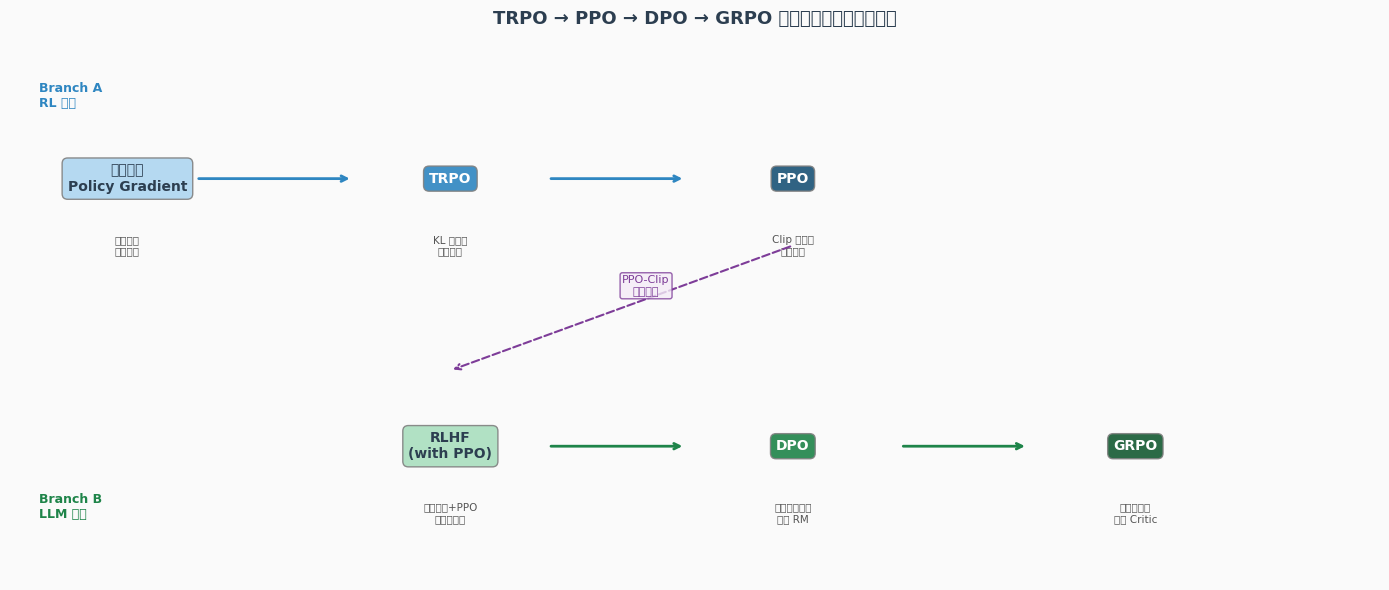

进化脉络图已生成


In [6]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.set_xlim(0, 14)
ax.set_ylim(0, 6)
ax.axis('off')
ax.set_facecolor('#fafafa')
fig.patch.set_facecolor('#fafafa')

# 节点定义：(x, y, label, sublabel, color)
nodes = [
    # Branch A
    (1.2, 4.5, "策略梯度\nPolicy Gradient", "基础方法\n步长难控", "#AED6F1"),
    (4.5, 4.5, "TRPO", "KL 硬约束\n二阶优化", "#2E86C1"),
    (8.0, 4.5, "PPO", "Clip 软约束\n一阶优化", "#1A5276"),
    # Branch B
    (4.5, 1.5, "RLHF\n(with PPO)", "奖励模型+PPO\n复杂但有效", "#A9DFBF"),
    (8.0, 1.5, "DPO", "直接偏好优化\n无需 RM", "#1E8449"),
    (11.5, 1.5, "GRPO", "组相对优化\n无需 Critic", "#145A32"),
]

for (x, y, label, sublabel, color) in nodes:
    box = dict(boxstyle='round,pad=0.4', facecolor=color, edgecolor='gray', alpha=0.9)
    ax.text(x, y, label, ha='center', va='center', fontsize=10, fontweight='bold',
            bbox=box, color='white' if color.startswith('#1') or color.startswith('#2') else '#2c3e50')
    ax.text(x, y - 0.75, sublabel, ha='center', va='center', fontsize=7.5, color='#555555')

# Branch A 箭头
for (x1, y1), (x2, y2) in [((1.9, 4.5), (3.5, 4.5)), ((5.5, 4.5), (6.9, 4.5))]:
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#2E86C1', lw=2))

# Branch B 箭头
for (x1, y1), (x2, y2) in [((5.5, 1.5), (6.9, 1.5)), ((9.1, 1.5), (10.4, 1.5))]:
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#1E8449', lw=2))

# PPO → RLHF 连接线（虚线，表示\"借用\"）
ax.annotate('', xy=(4.5, 2.35), xytext=(8.0, 3.75),
            arrowprops=dict(arrowstyle='->', color='#7D3C98', lw=1.5, linestyle='dashed'))
ax.text(6.5, 3.2, "PPO-Clip\n机制复用", ha='center', fontsize=8, color='#7D3C98',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='#F4ECF7', edgecolor='#7D3C98', alpha=0.8))

# 标签
ax.text(0.3, 5.3, "Branch A\nRL 控制", ha='left', fontsize=9, color='#2E86C1', fontweight='bold')
ax.text(0.3, 0.7, "Branch B\nLLM 对齐", ha='left', fontsize=9, color='#1E8449', fontweight='bold')

ax.set_title("TRPO → PPO → DPO → GRPO 进化脉络（两分支汇合）",
             fontsize=13, fontweight='bold', pad=15, color='#2c3e50')
plt.tight_layout()
plt.savefig('algorithm_evolution.png', dpi=120, bbox_inches='tight')
plt.show()
print("进化脉络图已生成")

## 横向对比表

（待所有 notebook 完成后填写完整数据）

In [7]:
data = {
    "维度":        ["约束机制", "是否需要 Critic", "是否需要参考模型", "适用场景", "计算代价", "关键超参"],
    "TRPO":        ["KL 硬约束（CG+线搜索）", "是（Value fn）", "否", "RL 精确控制", "高（二阶）", "δ (KL bound)"],
    "PPO":         ["Clip 软约束", "是（GAE）", "否", "RL 通用", "低（一阶）", "ε (clip ratio)"],
    "DPO":         ["隐式 KL（β 参数）", "否", "是（π_ref）", "LLM 偏好对齐", "低（监督学习）", "β (KL penalty)"],
    "GRPO":        ["Clip 软约束", "否", "是（π_ref 可选）", "LLM RLHF 替代", "中（采样密集）", "G (group size)"],
}

df = pd.DataFrame(data).set_index("维度")
print("=" * 60)
print("四种算法横向对比")
print("=" * 60)
print(df.to_string())

四种算法横向对比
                       TRPO             PPO             DPO            GRPO
维度                                                                         
约束机制         KL 硬约束（CG+线搜索）        Clip 软约束     隐式 KL（β 参数）        Clip 软约束
是否需要 Critic     是（Value fn）          是（GAE）               否               否
是否需要参考模型                  否               否        是（π_ref）     是（π_ref 可选）
适用场景                RL 精确控制           RL 通用        LLM 偏好对齐     LLM RLHF 替代
计算代价                  高（二阶）           低（一阶）         低（监督学习）         中（采样密集）
关键超参           δ (KL bound)  ε (clip ratio)  β (KL penalty)  G (group size)


## 核心公式速查

### TRPO
$$L(\theta) = \mathbb{E}_t\left[\frac{\pi_\theta(a_t|s_t)}{\pi_{\theta_{old}}(a_t|s_t)} A_t\right], \quad \text{s.t.} \quad \text{KL}(\pi_{old} \| \pi_{new}) \leq \delta$$

### PPO-Clip
$$L^{CLIP}(\theta) = \mathbb{E}_t\left[\min\left(r_t(\theta)A_t,\ \text{clip}(r_t(\theta), 1-\varepsilon, 1+\varepsilon)A_t\right)\right]$$

### DPO
$$\mathcal{L}_{DPO}(\pi_\theta) = -\mathbb{E}\left[\log \sigma\left(\beta \log\frac{\pi_\theta(y_w|x)}{\pi_{ref}(y_w|x)} - \beta \log\frac{\pi_\theta(y_l|x)}{\pi_{ref}(y_l|x)}\right)\right]$$

### GRPO
$$\hat{A}_i = \frac{R_i - \text{mean}(\{R_j\}_{j=1}^G)}{\text{std}(\{R_j\}_{j=1}^G)}, \quad L_{GRPO} = -\frac{1}{G}\sum_i \min\left(r_i \hat{A}_i,\ \text{clip}(r_i, 1-\varepsilon, 1+\varepsilon)\hat{A}_i\right)$$